# Module 05 — Cross-Dataset Integration: Three-Workflow Comparison (v5)

This notebook compares three integration workflows applied to the IVD
scRNA-seq atlas (12 datasets, ~411K cells). Each workflow was run per tissue
compartment (NP, AF, CEP) and on the combined all_cells object.

## Workflows

| Workflow | Language | Method | Reference |
|----------|----------|--------|-----------|
| **CCA** | R (Seurat v5) | Canonical Correlation Analysis | Stuart et al. 2019 |
| **scANVI** | Python (scvi-tools) | Semi-supervised variational inference | Xu et al. 2021 |
| **STACAS** | R | Semi-supervised anchoring with known cell types | Andreatta et al. 2021 |

## Downsampling

- **scANVI** integrated all cells (full dataset sizes)
- **CCA** downsampled NP to 15K cells and all_cells to 11K cells
- **STACAS** downsampled NP to 16K cells and all_cells to 30K cells
- AF and CEP were integrated at full size by all three workflows

**Pipeline version:** v5 (three-workflow comparison)

**Result files:**
- `results/integration/workflow_comparison.tsv` — metrics table
- `results/integration/workflow_comparison_metrics.png` — metrics bar chart
- `results/integration/umap_{cca,scanvi,stacas}_{NP,AF,CEP,all_cells}.png` — UMAP plots

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from PIL import Image

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
RESULTS_DIR = BASE / 'results' / 'integration'

# Verify result files exist
expected_files = ['workflow_comparison.tsv', 'workflow_comparison_metrics.png']
for obj in ['NP', 'AF', 'CEP', 'all_cells']:
    for wf in ['cca', 'scanvi', 'stacas']:
        expected_files.append(f'umap_{wf}_{obj}.png')

for f in expected_files:
    path = RESULTS_DIR / f
    status = 'found' if path.exists() else 'MISSING'
    print(f'  {f}: {status}')

  workflow_comparison.tsv: found
  workflow_comparison_metrics.png: found
  umap_cca_NP.png: found
  umap_scanvi_NP.png: found
  umap_stacas_NP.png: found
  umap_cca_AF.png: found
  umap_scanvi_AF.png: found
  umap_stacas_AF.png: found
  umap_cca_CEP.png: found
  umap_scanvi_CEP.png: found
  umap_stacas_CEP.png: found
  umap_cca_all_cells.png: found
  umap_scanvi_all_cells.png: found
  umap_stacas_all_cells.png: found


## 1. Workflow Comparison Table

Summary of all three workflows across all four objects, including cell counts,
cluster counts, and integration quality metrics (iLISI, batch ASW, condition ASW).
Metrics are only available for scANVI (computed in Python); CCA and STACAS
metrics would require additional computation.

In [2]:
comp_df = pd.read_csv(RESULTS_DIR / 'workflow_comparison.tsv', sep='\t')

# Format for display
display_df = comp_df[['object', 'workflow_label', 'language', 'status', 'n_cells',
                       'n_clusters_res05', 'iLISI', 'batch_ASW', 'condition_ASW']].copy()
display_df.columns = ['Object', 'Workflow', 'Language', 'Status', 'Cells',
                       'Clusters (res=0.5)', 'iLISI', 'Batch ASW', 'Condition ASW']

# Format numeric columns
for col in ['iLISI', 'Batch ASW', 'Condition ASW']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.3f}' if pd.notna(x) else '—')
display_df['Cells'] = display_df['Cells'].apply(lambda x: f'{int(x):,}' if pd.notna(x) else '—')
display_df['Clusters (res=0.5)'] = display_df['Clusters (res=0.5)'].apply(
    lambda x: f'{int(x)}' if pd.notna(x) else '—')

display(display_df.style.set_caption('Integration Workflow Comparison (v5)')
        .set_properties(**{'text-align': 'center'})
        .hide(axis='index'))

Object,Workflow,Language,Status,Cells,Clusters (res=0.5),iLISI,Batch ASW,Condition ASW
NP,CCA (Seurat v5),R,complete,"15,000",9,—,—,—
NP,scANVI,Python,complete,"262,967",—,1.233,0.082,0.004
NP,STACAS,R,complete,"16,000",21,—,—,—
AF,CCA (Seurat v5),R,complete,"84,624",23,—,—,—
AF,scANVI,Python,complete,"84,568",—,1.007,0.163,0.024
AF,STACAS,R,complete,"84,624",23,—,—,—
CEP,CCA (Seurat v5),R,complete,"50,858",14,—,—,—
CEP,scANVI,Python,complete,"50,769",—,1.029,0.205,0.044
CEP,STACAS,R,complete,"50,858",15,—,—,—
all_cells,CCA (Seurat v5),R,complete,"11,000",8,—,—,—


## 2. UMAP Comparisons by Compartment

Side-by-side UMAPs for each object across all three workflows. Each UMAP shows
cells colored by study and/or condition, allowing visual assessment of batch
mixing and biological signal preservation.

Note on cell counts:
- **NP**: CCA 15K, scANVI 263K, STACAS 16K
- **AF**: all workflows ~84.6K cells (full dataset)
- **CEP**: all workflows ~50.8K cells (full dataset)
- **all_cells**: CCA 11K, scANVI 411K, STACAS 30K

In [3]:
def show_umap_comparison(obj_name, title):
    """Display side-by-side UMAPs for CCA, scANVI, STACAS for a given object."""
    workflows = ['cca', 'scanvi', 'stacas']
    labels = ['CCA (Seurat v5)', 'scANVI', 'STACAS']
    
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    
    for ax, wf, label in zip(axes, workflows, labels):
        img_path = RESULTS_DIR / f'umap_{wf}_{obj_name}.png'
        if img_path.exists():
            img = mpimg.imread(str(img_path))
            ax.imshow(img)
            ax.set_title(label, fontsize=14, fontweight='bold')
        else:
            ax.text(0.5, 0.5, f'{label}\nNot available',
                    ha='center', va='center', fontsize=14, transform=ax.transAxes)
        ax.axis('off')
    
    fig.suptitle(f'{title}', fontsize=16, fontweight='bold', y=1.02)
    fig.tight_layout()
    plt.show()

### 2a. NP — Nucleus Pulposus

The NP compartment is the largest object (~263K cells). CCA and STACAS used
downsampled subsets (15K and 16K respectively) due to memory constraints in R,
while scANVI integrated all cells.

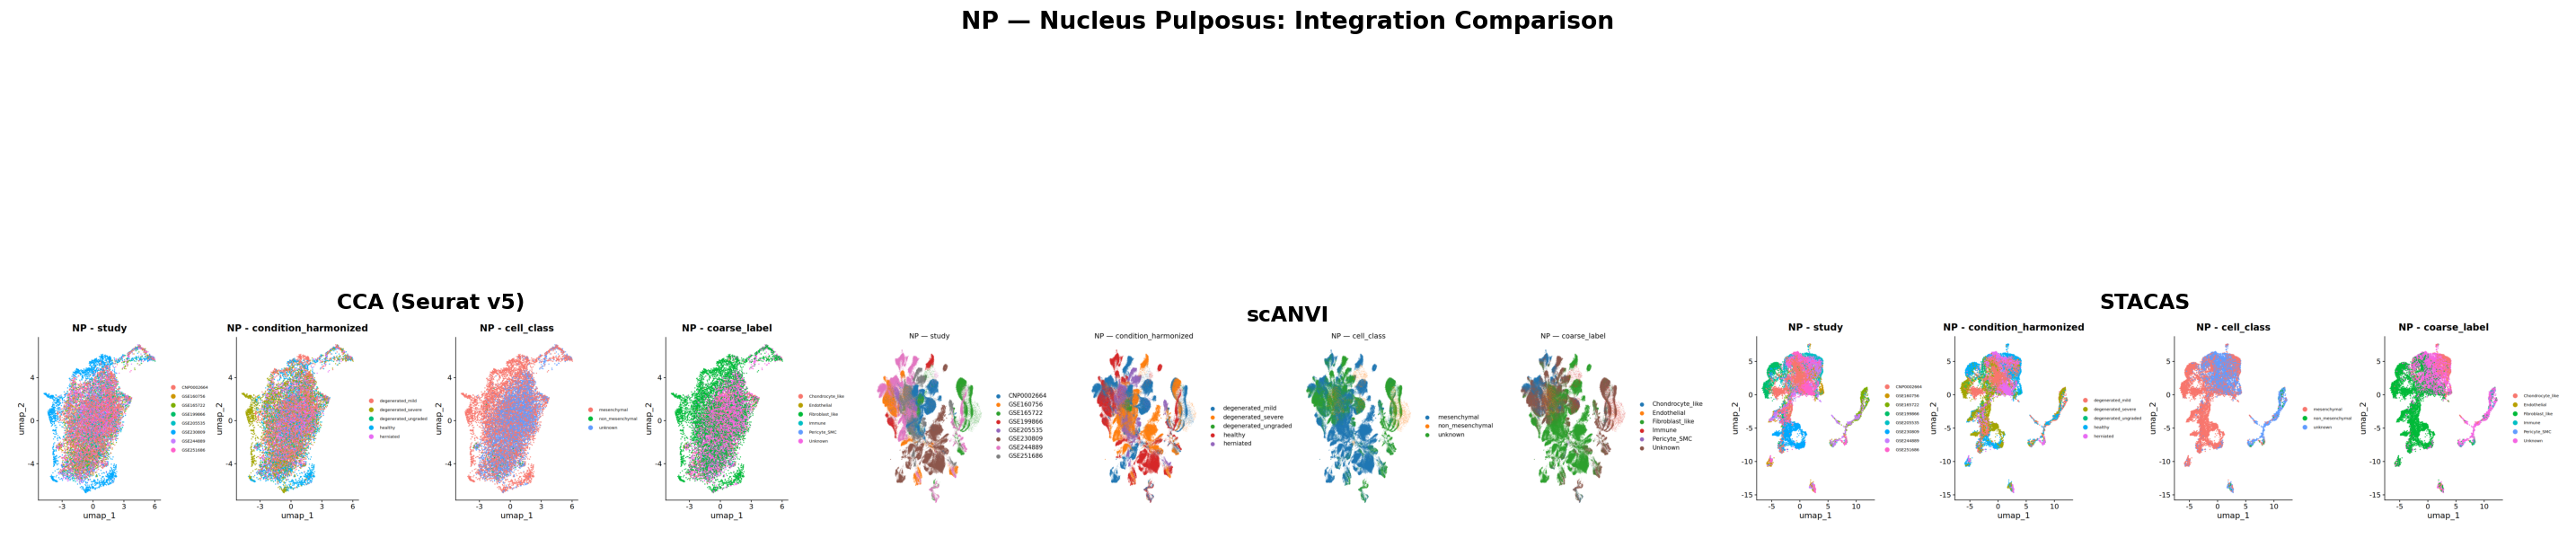

In [4]:
show_umap_comparison('NP', 'NP — Nucleus Pulposus: Integration Comparison')

### 2b. AF — Annulus Fibrosus

The AF compartment (~84.6K cells) was integrated at full size by all three
workflows, allowing direct comparison without downsampling confounds.

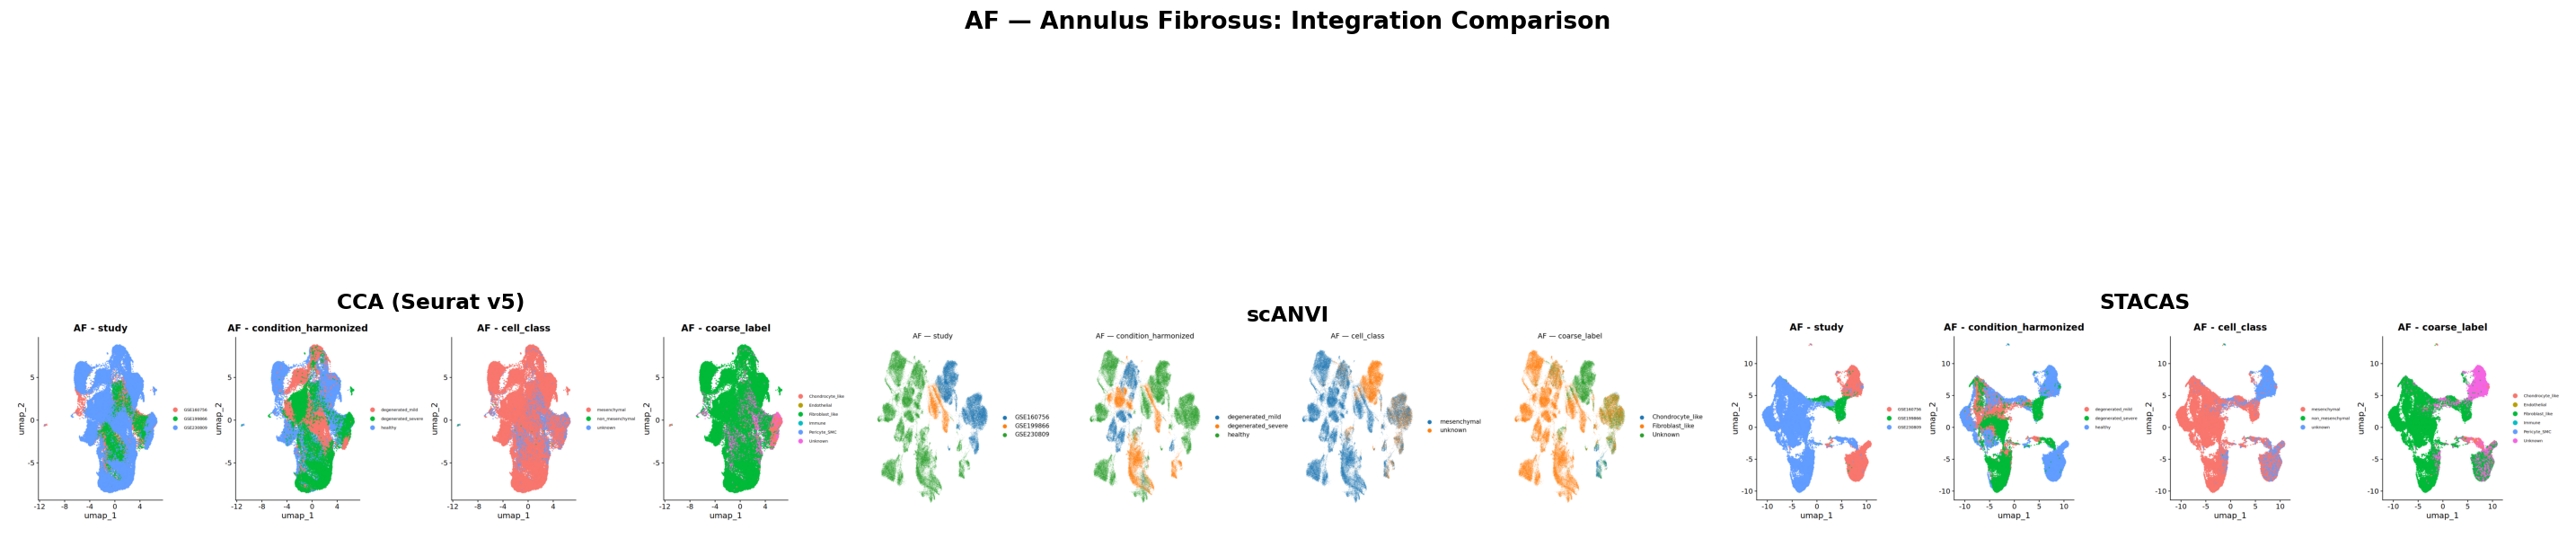

In [5]:
show_umap_comparison('AF', 'AF — Annulus Fibrosus: Integration Comparison')

### 2c. CEP — Cartilaginous Endplate

The CEP compartment (~50.8K cells) was integrated at full size by all three
workflows.

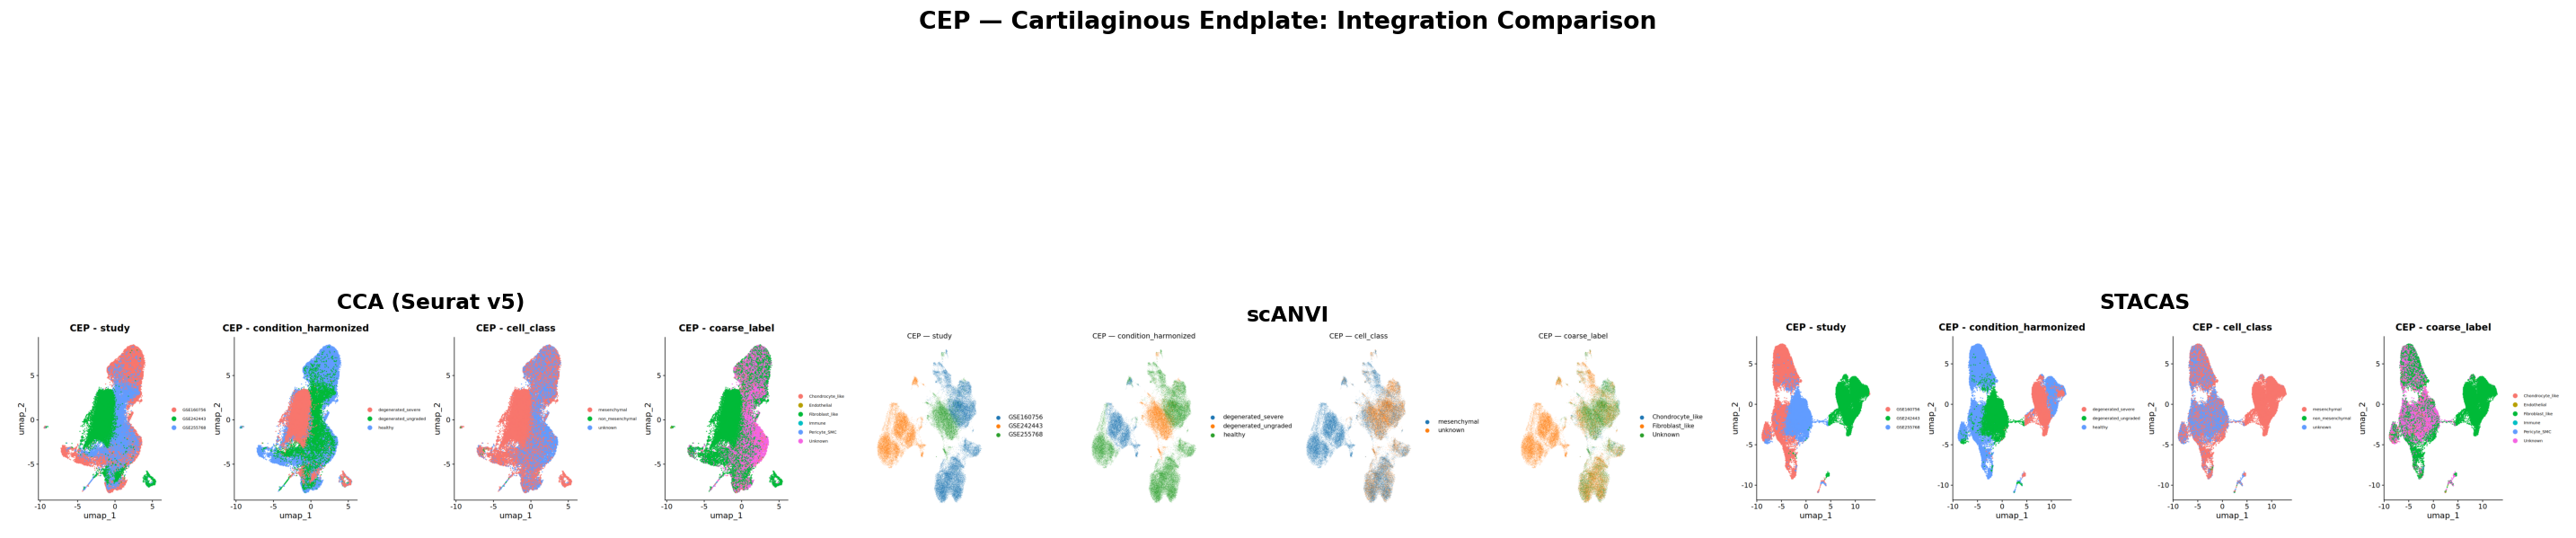

In [6]:
show_umap_comparison('CEP', 'CEP — Cartilaginous Endplate: Integration Comparison')

### 2d. all_cells — Combined Object

The combined object (~411K cells) includes all compartments. CCA downsampled
to 11K cells and STACAS to 30K cells; scANVI integrated all 411K cells.

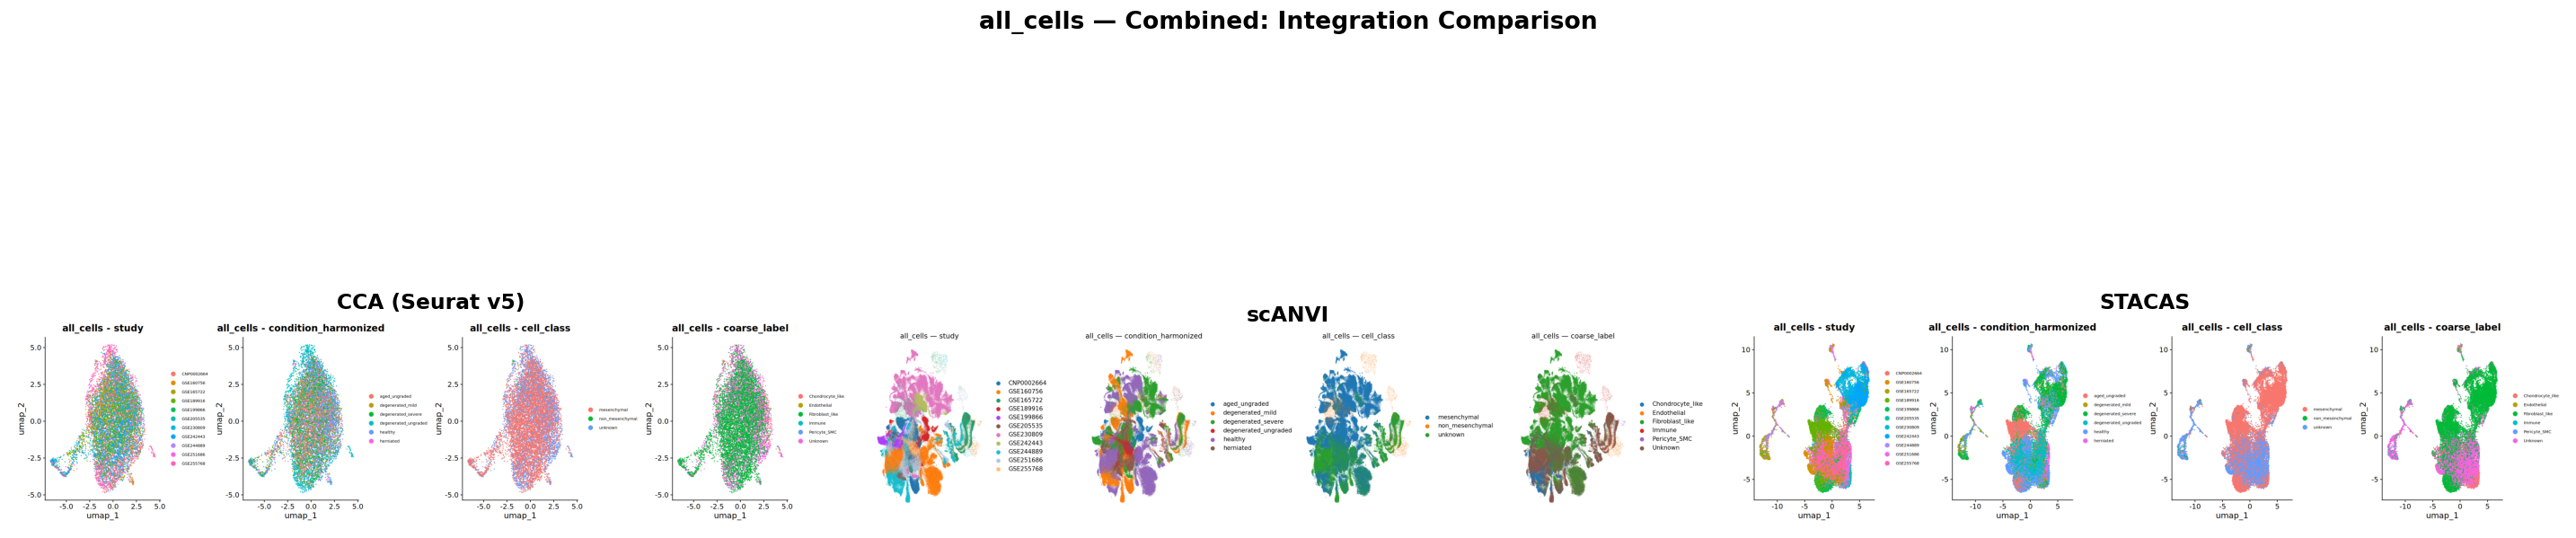

In [7]:
show_umap_comparison('all_cells', 'all_cells — Combined: Integration Comparison')

## 3. Integration Metrics Comparison

Bar chart comparing integration quality metrics across workflows. Metrics
shown (where available):
- **iLISI** (integration Local Inverse Simpson's Index): higher = better batch mixing
- **Batch ASW** (Average Silhouette Width by batch): closer to 0 = better mixing
- **Condition ASW**: closer to 0 = condition signal not over-corrected

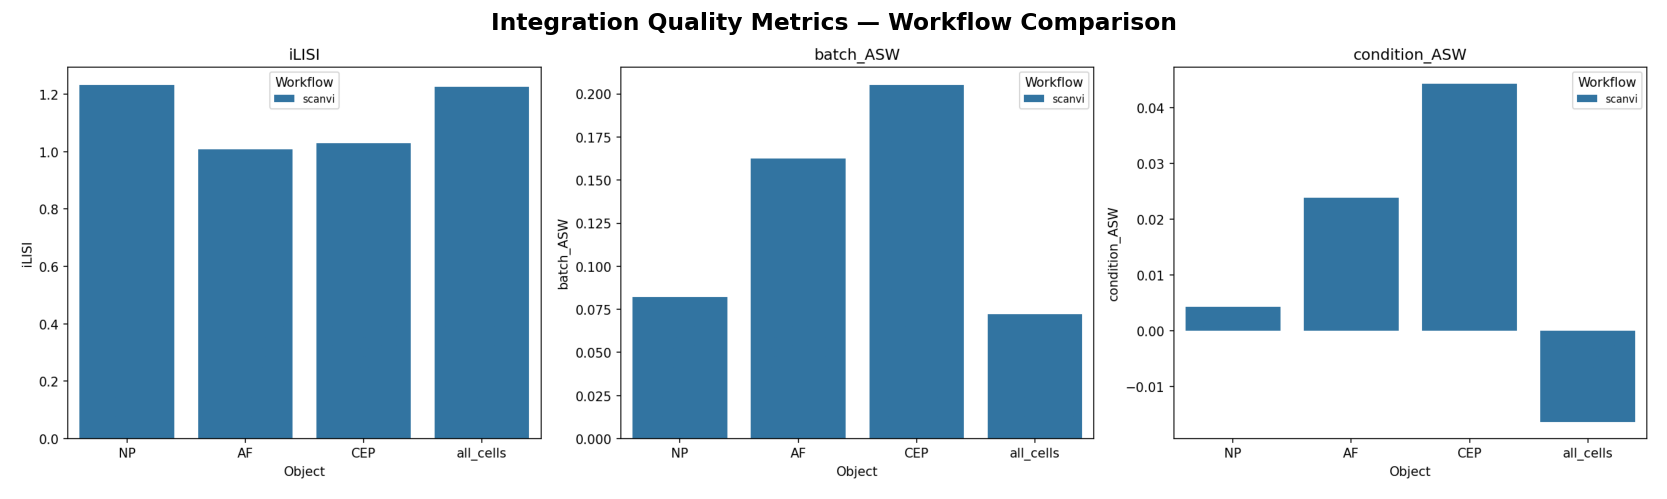

In [8]:
metrics_path = RESULTS_DIR / 'workflow_comparison_metrics.png'
if metrics_path.exists():
    fig, ax = plt.subplots(figsize=(14, 8))
    img = mpimg.imread(str(metrics_path))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('Integration Quality Metrics — Workflow Comparison', fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.show()
else:
    print('Metrics comparison plot not found')

## 4. Workflow Summary

### CCA (Seurat v5, R)
- **Method**: Canonical Correlation Analysis with mutual nearest neighbors anchoring
- **Approach**: Identifies shared correlation structure across datasets, then
  aligns cells using anchor pairs
- **Downsampling**: NP to 15K cells, all_cells to 11K cells (R memory constraints)
- **Strengths**: Well-established, widely used in the field
- **Limitations**: Linear method; downsampling means not all cells receive
  integrated embeddings

### scANVI (scvi-tools, Python)
- **Method**: Semi-supervised variational autoencoder using known cell type labels
  as guidance
- **Approach**: Learns a latent space that accounts for batch effects while
  preserving biological variation, guided by coarse anchor annotations
- **Downsampling**: None (integrated all cells)
- **Strengths**: Nonlinear; handles large datasets efficiently on GPU; provides
  uncertainty estimates; full integration of all cells
- **Limitations**: Requires GPU; model training is stochastic

### STACAS (R)
- **Method**: Semi-supervised anchor-based integration using known cell type
  labels to guide anchor filtering
- **Approach**: Extends Seurat's integration by filtering anchors that connect
  cells of different known types, reducing over-correction
- **Downsampling**: NP to 16K cells, all_cells to 30K cells (R memory constraints)
- **Strengths**: Leverages prior knowledge to prevent mixing of distinct populations
- **Limitations**: Anchor-based; downsampling required for large objects

### Key Observations
- All three workflows completed successfully across all four objects
- scANVI is the only workflow that integrated the full cell counts without downsampling
- CCA and STACAS cluster counts at resolution 0.5 provide a rough sense of
  structure granularity, but are not directly comparable to scANVI (different
  embedding spaces)
- Integration metrics (iLISI, batch ASW, condition ASW) are currently only
  computed for scANVI; cross-workflow metric comparison would require
  projecting all workflows into a common evaluation framework